# Baseline CNN

🎯 **Goal**: Establish a simple end-to-end baseline for bird species classification using a CNN trained from scratch.

**Approach**

- Use the CUB-200-2011 dataset with predefined train/test split
- Create a validation split from training data
- Build a small CNN with convolution + pooling layers
- Train on resized and normalised images (224x224)
- Evaluate performance on validation and test sets
- Log results using MLflow

### Executive Summary
The baseline CNN performs at approximately random chance (~0.5% accuracy) 👉 the model is not learning meaningful features. This confirms the data pipeline and training loop are working correctly, and highlights the need for a more powerful modelling approach. This baseline provides a reference point for evaluating improvements from transfer learning.

### Imports

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

from beakspeak.data import load_metadata, create_dataset, split_data
from beakspeak.params import (
    IMG_HEIGHT,
    IMG_WIDTH,
    BATCH_SIZE,
    EPOCHS,
    LEARNING_RATE,
    SEED,
    NUM_CLASSES,
)

# --- mlflow setup ---
mlflow.set_tracking_uri("sqlite:///../mlruns.db")
MLFLOW_EXPERIMENT_NAME = "beakspeak-baseline"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

# --- paths ---
DATA_DIR = Path("../data/CUB_200_2011/CUB_200_2011")

# --- tf performance ---
AUTOTUNE = tf.data.AUTOTUNE

# --- Checks ---
print("cwd:", os.getcwd())
print("tracking uri:", mlflow.get_tracking_uri())
print("resolved tracking path:", (Path.cwd() / "../mlruns").resolve())

2026/04/10 20:54:30 INFO mlflow.tracking.fluent: Experiment with name 'beakspeak-baseline' does not exist. Creating a new experiment.


cwd: /Users/keira/Documents/projects/beakspeak/notebooks
tracking uri: sqlite:///../mlruns.db
resolved tracking path: /Users/keira/Documents/projects/beakspeak/mlruns


## Prepare data

In [2]:
# Load and split data
df = load_metadata(DATA_DIR)
train_df, val_df, test_df = split_data(df)

# Check data
print("Full dataset:", df.shape)
print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

print("\nUnique classes:")
print("Train:", train_df["class_id"].nunique())
print("Val:", val_df["class_id"].nunique())
print("Test:", test_df["class_id"].nunique())

Full dataset: (11788, 7)
Train set: (4795, 7)
Validation set: (1199, 7)
Test set: (5794, 7)

Unique classes:
Train: 200
Val: 200
Test: 200


In [3]:
# ---- Prepare labels for TensorFlow ----

# Adjust class IDs to be zero-indexed
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

print("Number of unique classes:", train_df["label"].nunique())
print("Labels:", train_df["label"].head(10).tolist())

Number of unique classes: 200
Labels: [61, 87, 104, 7, 1, 34, 145, 66, 109, 102]


## TensorFlow input pipeline

In [4]:
def load_and_preprocess_image(file_path, label):
    """
    Load and preprocess a single image.

    Inputs:
    - file_path: Path to the image file
    - label: Integer class label

    Outputs:
    - image: Preprocessed image tensor of shape (224, 224, 3)
    - label: Unchanged integer class label
    """

    # Read raw file
    image = tf.io.read_file(file_path)

    # Decode JPEG into 3-channel RGB image
    image = tf.image.decode_jpeg(image, channels=3)

    # Set image shape
    image.set_shape([None, None, 3])

    # Resize for CNN processing and preserve aspect ratio
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH], preserve_aspect_ratio=True)

    # Pad to ensure final size is (224, 224)
    image = tf.image.resize_with_pad(image, IMG_HEIGHT, IMG_WIDTH)

    # Scale pixel values to [0, 1]
    image = image / 255.0

    return image, label

In [5]:
def create_dataset(df, shuffle=True):
    """
    Create a TensorFlow dataset from a DataFrame of image paths and labels.

    Parameters:
    - df: DataFrame with 'file_path' and 'label' columns
    - shuffle: True for train, False for val/test

    Returns:
    - A batched tf.data.Dataset object
    """

    # Create dataset from pairs of image paths and labels
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["file_path"].astype(str).values,
            df["label"].values
        )
    )

    # Shuffle for training across length of training set
    # Not for validation/test
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED
        )

    # Map the loading and preprocessing function across the dataset
    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    # Batch the dataset for efficient training
    dataset = dataset.batch(BATCH_SIZE)

    # Prefetch to improve performance
    # Overlapping data preprocessing and model execution
    # (Fetches the next batch while the current batch is being processed)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

## Create train, val, and test datasets

In [6]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [7]:
# Inspect a batch
for images, labels in train_ds.take(1):
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)
    print("Unique labels in batch:", np.unique(labels.numpy()))

Batch of images shape: (32, 224, 224, 3)
Batch of labels shape: (32,)
Unique labels in batch: [  4   5   8  14  15  22  45  48  52  57  68  91  93 121 124 125 128 137
 138 140 148 152 158 175 182 183 185 198]


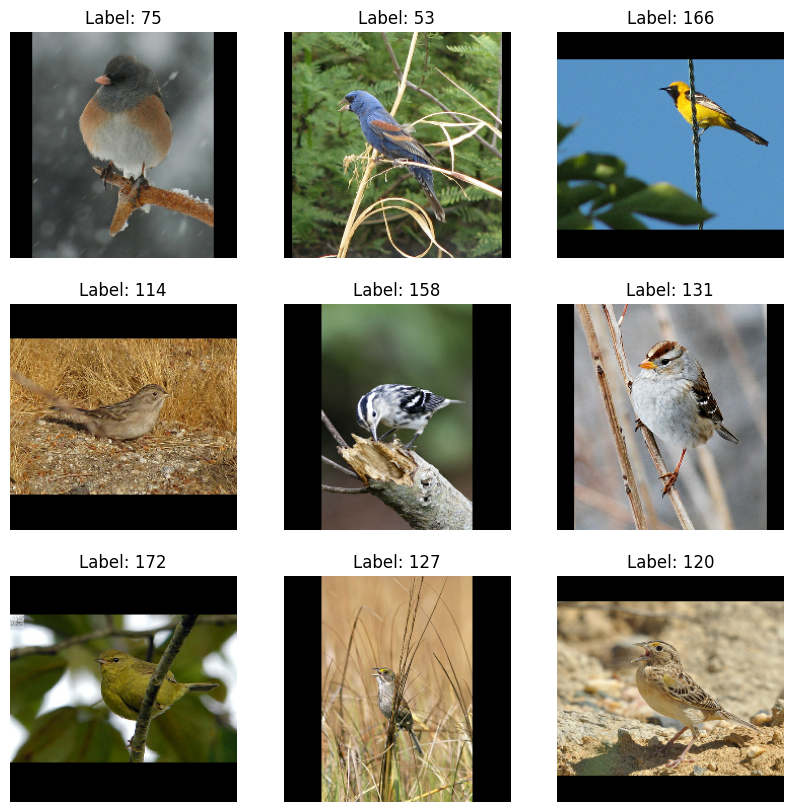

In [8]:
# Confirm with a few images
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image[0].numpy())
    plt.title(f"Label: {label[0].numpy()}")
    plt.axis("off")

## Baseline CNN

🙋‍♀️ This model is intentionally simple. The goal is to establish a reliable baseline for comparison.

Overall structure:
```Conv → Pool → Conv → Pool → Conv → Pool → Dense → Output```

- Extract features
- Reduce spatial size
- Combine features into predictions

In [11]:
def build_baseline_cnn(num_classes=NUM_CLASSES):
    """
    Build a simple CNN model for multiclass image classification.

    Returns:
    - A compiled Keras model
    """

    model = tf.keras.Sequential([

        # Input layer
        tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Convolution block 1
        # Learn small local features with 3x3 filters
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # Convolution block 2
        # Learn more complex features with more filters
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # Convolution block 3
        # Deeper layer to learn higher-level features
        tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # Flatten the 3D feature maps to 1D feature vectors
        tf.keras.layers.Flatten(),

        # Combine extracted features
        tf.keras.layers.Dense(128, activation="relu"),

        # Reduce overfitting with dropout
        tf.keras.layers.Dropout(0.3),

        # Output layer gives one probability per class
        # No softmax activation here -> loss function will use from_logits=True
        tf.keras.layers.Dense(num_classes)
    ])

    return model

In [12]:
model = build_baseline_cnn(NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,194,760 (42.70 MB)

 Trainable params: 11,194,760 (42.70 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ---- Compile the model ----
# - update weights with Adam optimization algorithm
# - use sparse categorical crossentropy loss for integer labels
# - from_logits=True because the output layer does not have softmax activation
# - track accuracy metric during training and evaluation

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [15]:
# ---- Train the model and log metrics to MLflow ----

with mlflow.start_run(run_name="baseline_cnn"):

    # Log parameters
    mlflow.log_param("model_type", "baseline_cnn")
    mlflow.log_param("image_height", IMG_HEIGHT)
    mlflow.log_param("image_width", IMG_WIDTH)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("num_classes", NUM_CLASSES)

    # Train the model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    # Evaluate on validation and test sets
    val_loss, val_accuracy = model.evaluate(val_ds)
    test_loss, test_accuracy = model.evaluate(test_ds)

    # Log metrics
    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")


Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 354ms/step - accuracy: 0.0031 - loss: 5.3092 - val_accuracy: 0.0075 - val_loss: 5.2983
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 92s 614ms/step - accuracy: 0.0048 - loss: 5.2962 - val_accuracy: 0.0042 - val_loss: 5.2909
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 101s 674ms/step - accuracy: 0.0092 - loss: 5.2607 - val_accuracy: 0.0083 - val_loss: 5.2627
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 96s 639ms/step - accuracy: 0.0248 - loss: 5.1135 - val_accuracy: 0.0150 - val_loss: 5.1790
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.0797 - loss: 4.5695 - val_accuracy: 0.0142 - val_loss: 5.2792
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.0142 - loss: 5.2792
182/182 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.0217 - loss: 5.2469
Validation Accuracy: 0.0142
Test Accuracy: 0.0217


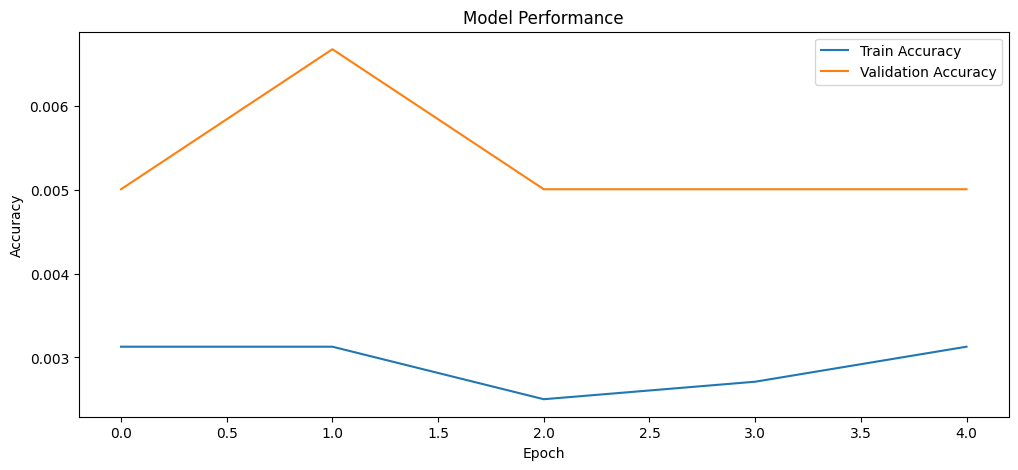

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Performance")
plt.legend()
plt.show()

### 💡 Baseline CNN: Performance & Interpretation

**This baseline model is effectively performing at random.**

Accuracy sits at ~0.5% across validation and test sets, which is expected for a 200-class problem (1/200 ≈ 0.5%). The loss (~5.30) also aligns with log(200), indicating near-uniform predictions across classes.

Training and validation curves are flat, with no meaningful improvement over epochs and no divergence between them. This rules out overfitting - the model isn’t learning useful features at all.

That’s a useful outcome in itself. It confirms that:
- the data pipeline is working end-to-end
- labels are correctly aligned
- training is behaving as expected

👉 So the limitation is model capability, not implementation.

Given the problem (fine-grained classification across 200 visually similar bird species), this result is expected. The small CNN is both too simple to capture fine-grained visual differences between species, and is starting from scratch without any prior understanding of visual patterns.

🎯 Next: Move to transfer learning and leverage pre-trained feature extractors.

In [ ]:
# Save the model
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

model.save(models_dir / "baseline_cnn.keras")